In [455]:
!pip install pandas numpy datetime matplotlib statsmodels scipy

In [456]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR
from scipy.stats import pearsonr

## Reading the Data

In [457]:
def date_parser(s):
    return datetime.strptime(s, '%Y-%m')

In [458]:
df = pd.read_csv('data.csv', parse_dates=[0], index_col=0)

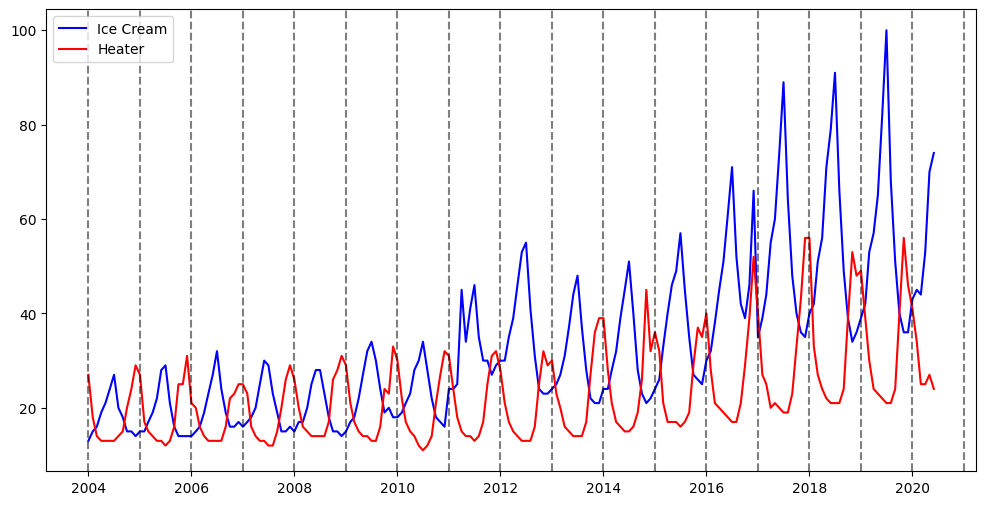

In [459]:
df = df.asfreq(pd.infer_freq(df.index))
plt.figure(figsize=(12, 6))
ice_cream, = plt.plot(df['ice cream'], color='blue')
heater, = plt.plot(df['heater'], color='red')

# add vertical lines to separate years
# plt.axvline(x=0, ymin=0, ymax=1)
for y in range(2004, 2022):
    plt.axvline(datetime(y,1,1), linestyle="--", color='k', alpha=0.5)
    
plt.legend(['Ice Cream', 'Heater'])

Data is non stationary since there is no constant mean and variance. We need to first make it stationary.

In [460]:
avgs = df.mean()
devs = df.std()
print(avgs, "\n\n", devs)

heater       22.792929
ice cream    33.060606
dtype: float64 

 heater        9.795500
ice cream    17.073635
dtype: float64


In [461]:
for col in df.columns:
    df[col] = (df[col] - avgs.loc[col]) / devs.loc[col]

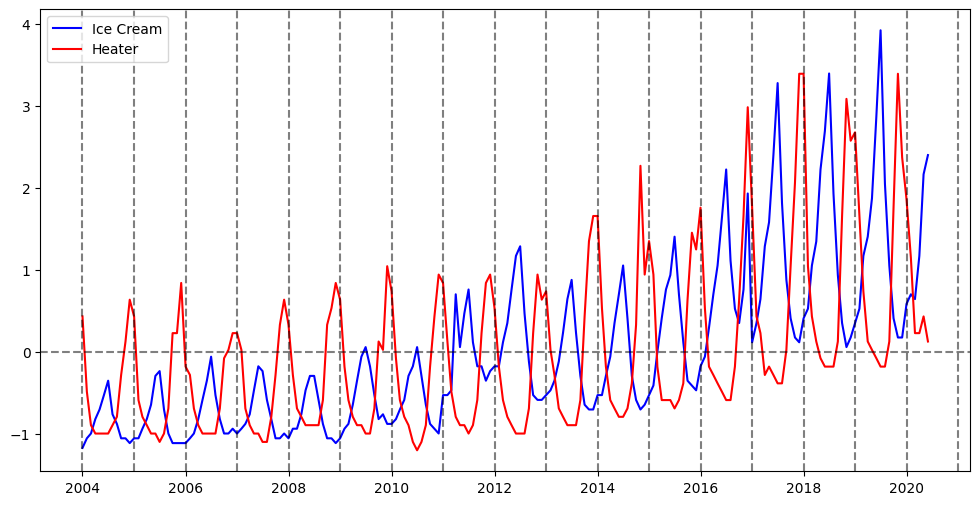

In [462]:
df = df.asfreq(pd.infer_freq(df.index))
plt.figure(figsize=(12, 6))
ice_cream, = plt.plot(df['ice cream'], color='blue')
heater, = plt.plot(df['heater'], color='red')

# add vertical lines to separate years
# plt.axvline(x=0, ymin=0, ymax=1)
for y in range(2004, 2022):
    plt.axvline(datetime(y,1,1), linestyle="--", color='k', alpha=0.5)
plt.axhline(0, linestyle="--", color='k', alpha=0.5)
plt.legend(['Ice Cream', 'Heater'])

# Take the first difference to remove the trend

In [463]:
df = df.diff().dropna()
print(df)

              heater  ice cream
Month                          
2004-02-01 -0.918789   0.117140
2004-03-01 -0.408351   0.058570
2004-04-01 -0.102088   0.175710
2004-05-01  0.000000   0.117140
2004-06-01  0.000000   0.175710
...              ...        ...
2020-02-01 -0.714614   0.117140
2020-03-01 -0.918789  -0.058570
2020-04-01  0.000000   0.527129
2020-05-01  0.204175   0.995687
2020-06-01 -0.306263   0.234279

[197 rows x 2 columns]


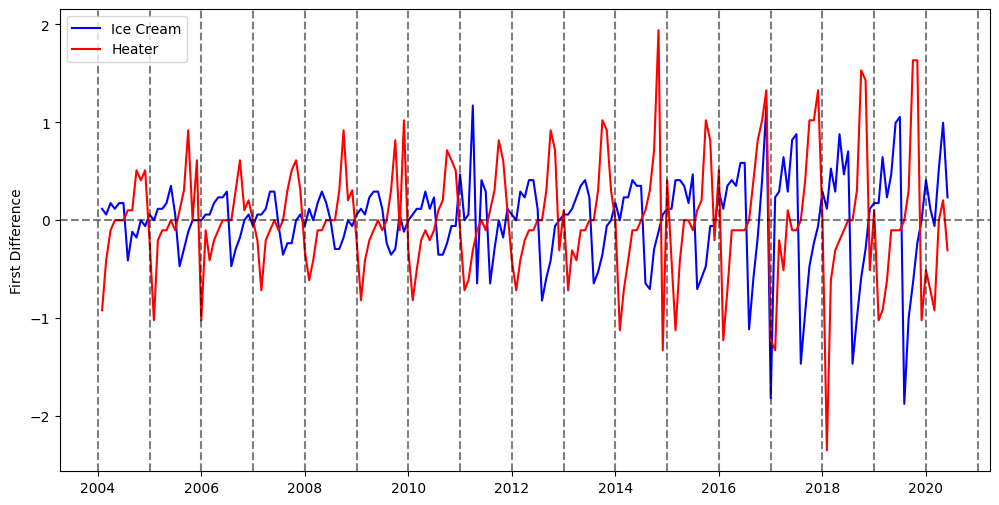

In [464]:
plt.figure(figsize=(12, 6))
ice_cream, = plt.plot(df['ice cream'], color='blue')
heater, = plt.plot(df['heater'], color='red')

# add vertical lines to separate years
# plt.axvline(x=0, ymin=0, ymax=1)
for y in range(2004, 2022):
    plt.axvline(datetime(y,1,1), linestyle="--", color='k', alpha=0.5)
plt.axhline(0, linestyle="--", color='k', alpha=0.5)
plt.ylabel("First Difference")
plt.legend(['Ice Cream', 'Heater'])

In [465]:
# group by year and see the annualized standard deviation
annual_vol = df.groupby(df.index.year).std()
annual_vol.head()

,heater,ice cream
Month,,
2004,0.415481,0.184201
2005,0.474527,0.214837
2006,0.400148,0.227698
2007,0.359839,0.198947
2008,0.396182,0.183239


In [466]:
df['ic_annual_vol'] = df.index.map(lambda d: annual_vol.loc[d.year, 'ice cream'])
df['h_annual_vol'] = df.index.map(lambda d: annual_vol.loc[d.year, 'heater'])
df = df[['ice cream', 'ic_annual_vol', 'heater', 'h_annual_vol']]
df.head()

,ice cream,ic_annual_vol,heater,h_annual_vol
Month,,,,
2004-02-01,0.11714,0.184201,-0.918789,0.415481
2004-03-01,0.05857,0.184201,-0.408351,0.415481
2004-04-01,0.17571,0.184201,-0.102088,0.415481
2004-05-01,0.11714,0.184201,0.000000,0.415481
2004-06-01,0.17571,0.184201,0.000000,0.415481


In [467]:
df['ice cream'] = df['ice cream'] / df['ic_annual_vol']
df['heater'] = df['heater'] / df['h_annual_vol']

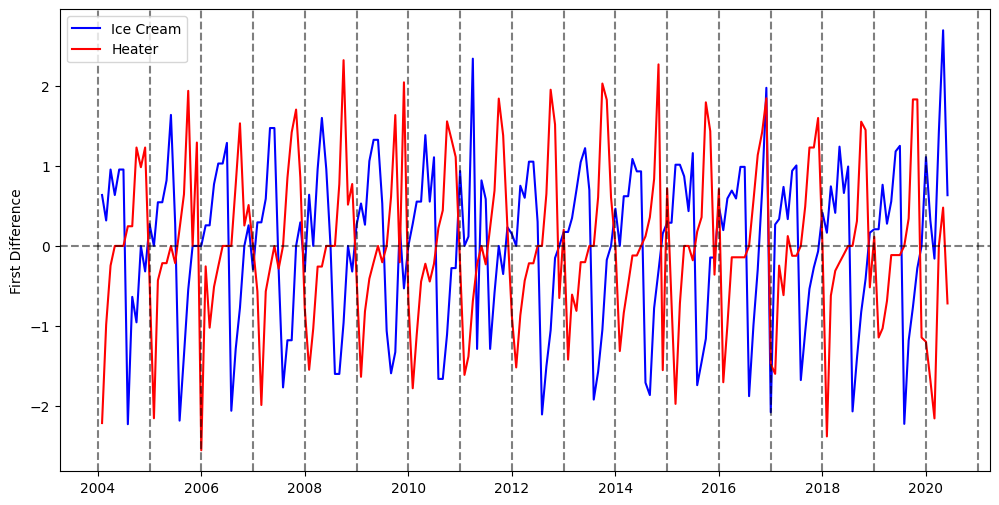

In [468]:
plt.figure(figsize=(12, 6))
ice_cream, = plt.plot(df['ice cream'], color='blue')
heater, = plt.plot(df['heater'], color='red')

# add vertical lines to separate years
# plt.axvline(x=0, ymin=0, ymax=1)
for y in range(2004, 2022):
    plt.axvline(datetime(y,1,1), linestyle="--", color='k', alpha=0.5)
plt.axhline(0, linestyle="--", color='k', alpha=0.5)
plt.ylabel("First Difference")
plt.legend(['Ice Cream', 'Heater'])

# Remove seasonality

In [469]:
df

,ice cream,ic_annual_vol,heater,h_annual_vol
Month,,,,
2004-02-01,0.635934,0.184201,-2.211387,0.415481
2004-03-01,0.317967,0.184201,-0.982838,0.415481
2004-04-01,0.953901,0.184201,-0.245710,0.415481
2004-05-01,0.635934,0.184201,0.000000,0.415481
2004-06-01,0.953901,0.184201,0.000000,0.415481
...,...,...,...,...
2020-02-01,0.316756,0.369810,-1.674916,0.426657
2020-03-01,-0.158378,0.369810,-2.153463,0.426657
2020-04-01,1.425403,0.369810,0.000000,0.426657


In [470]:
# group by month
monthly_avgs = df.groupby(df.index.month).mean()
monthly_avgs.head(20)

,ice cream,ic_annual_vol,heater,h_annual_vol
Month,,,,
1,0.130345,0.415976,-0.428360,0.580717
2,0.250194,0.402342,-1.483129,0.570997
3,0.433016,0.402342,-1.063595,0.570997
4,0.838085,0.402342,-0.442926,0.570997
5,0.967273,0.402342,-0.121663,0.570997
6,0.987311,0.402342,-0.128425,0.570997
7,0.735052,0.404376,-0.107093,0.580018
8,-1.821285,0.404376,0.075720,0.580018
9,-1.307661,0.404376,0.544638,0.580018


In [471]:
df['ice_cream_month_avg'] = df.index.map(lambda d: monthly_avgs.loc[d.month, 'ice cream'])
df['heater_month_avg'] = df.index.map(lambda d: monthly_avgs.loc[d.month, 'heater'])
df.head()

,ice cream,ic_annual_vol,heater,h_annual_vol,ice_cream_month_avg,heater_month_avg
Month,,,,,,
2004-02-01,0.635934,0.184201,-2.211387,0.415481,0.250194,-1.483129
2004-03-01,0.317967,0.184201,-0.982838,0.415481,0.433016,-1.063595
2004-04-01,0.953901,0.184201,-0.245710,0.415481,0.838085,-0.442926
2004-05-01,0.635934,0.184201,0.000000,0.415481,0.967273,-0.121663
2004-06-01,0.953901,0.184201,0.000000,0.415481,0.987311,-0.128425


In [472]:
df['ice cream'] = df['ice cream'] - df['ice_cream_month_avg']
df['heater'] = df['heater'] - df['heater_month_avg']
df.head()

,ice cream,ic_annual_vol,heater,h_annual_vol,ice_cream_month_avg,heater_month_avg
Month,,,,,,
2004-02-01,0.385740,0.184201,-0.728257,0.415481,0.250194,-1.483129
2004-03-01,-0.115049,0.184201,0.080757,0.415481,0.433016,-1.063595
2004-04-01,0.115816,0.184201,0.197217,0.415481,0.838085,-0.442926
2004-05-01,-0.331339,0.184201,0.121663,0.415481,0.967273,-0.121663
2004-06-01,-0.033411,0.184201,0.128425,0.415481,0.987311,-0.128425


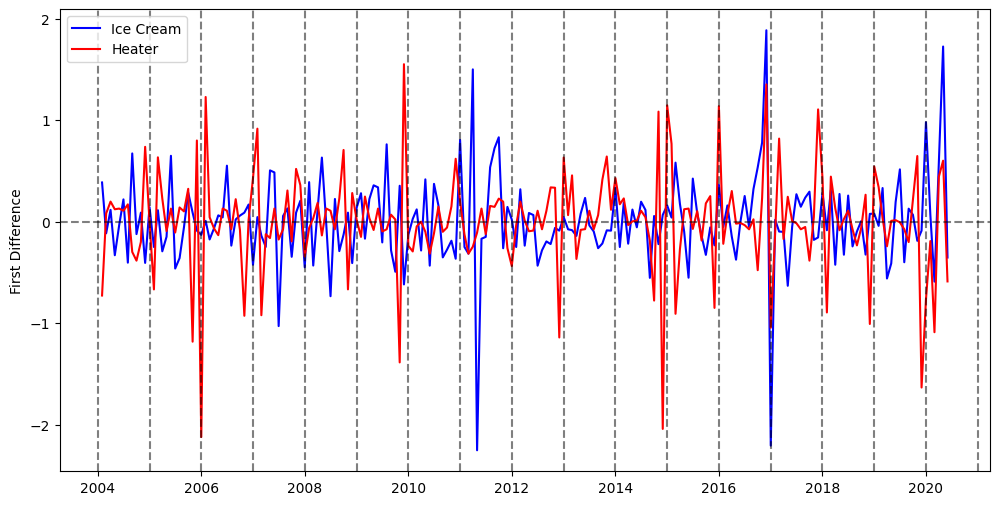

In [473]:
plt.figure(figsize=(12, 6))
ice_cream, = plt.plot(df['ice cream'], color='blue')
heater, = plt.plot(df['heater'], color='red')

# add vertical lines to separate years
# plt.axvline(x=0, ymin=0, ymax=1)
for y in range(2004, 2022):
    plt.axvline(datetime(y,1,1), linestyle="--", color='k', alpha=0.5)
plt.axhline(0, linestyle="--", color='k', alpha=0.5)
plt.ylabel("First Difference")
plt.legend(['Ice Cream', 'Heater'])

# Now the series are stationary with constant mean and variance

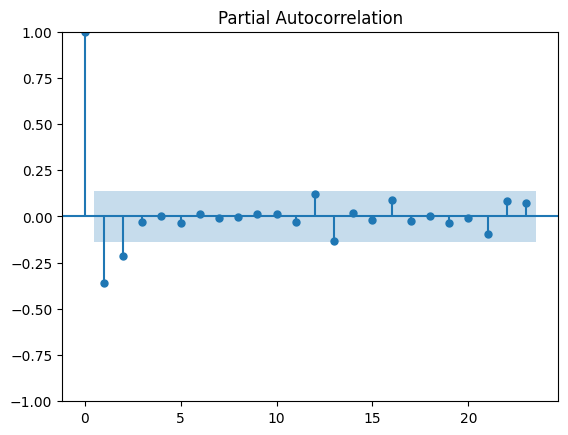

In [474]:
plot_pacf(df['heater'])
plt.show()

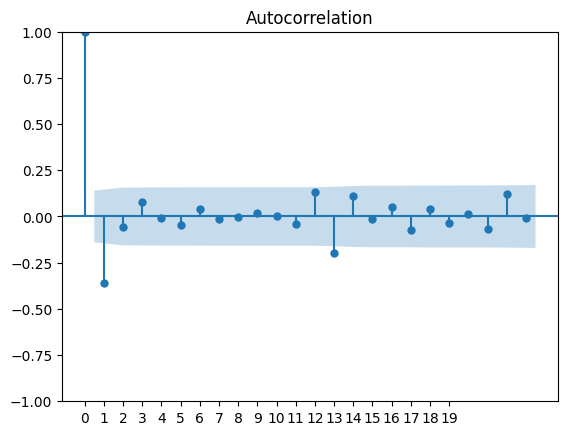

In [475]:
plot_acf(df['heater'])
plt.xticks([x for x in range(0, 20)])
plt.show()

# We can consider an AR(2) model since the 2 lags are significant. 

In [476]:
for lag in range(1, 14):
    heater_series = df['heater'].iloc[lag:]
    lagged_ice_cream_series = df['ice cream'].iloc[:-lag]
    print('Lag: %s'%lag)
    print(tuple(pearsonr(heater_series, lagged_ice_cream_series)))
    print('------')

Lag: 1
(np.float64(-0.03154450742591566), np.float64(0.6607284991749388))
------
Lag: 2
(np.float64(-0.09872703210944636), np.float64(0.16970841905089776))
------
Lag: 3
(np.float64(-0.0017838553789235878), np.float64(0.9803056762960969))
------
Lag: 4
(np.float64(0.06023971859825539), np.float64(0.4052979832528642))
------
Lag: 5
(np.float64(-0.05403486448015027), np.float64(0.45664426275056946))
------
Lag: 6
(np.float64(0.06461183026553834), np.float64(0.37453000434454303))
------
Lag: 7
(np.float64(-0.04949334618415864), np.float64(0.4976876685762085))
------
Lag: 8
(np.float64(0.07890837135977344), np.float64(0.2804548970433061))
------
Lag: 9
(np.float64(-0.053235016996004275), np.float64(0.46810342022280294))
------
Lag: 10
(np.float64(0.029536989060791153), np.float64(0.6882054906333296))
------
Lag: 11
(np.float64(-0.05979536351522567), np.float64(0.4175217420485686))
------
Lag: 12
(np.float64(-0.07513046035981794), np.float64(0.3094409252542687))
------
Lag: 13
(np.float64(0

# Fitting the VAR Model

In [477]:
df.head()

,ice cream,ic_annual_vol,heater,h_annual_vol,ice_cream_month_avg,heater_month_avg
Month,,,,,,
2004-02-01,0.385740,0.184201,-0.728257,0.415481,0.250194,-1.483129
2004-03-01,-0.115049,0.184201,0.080757,0.415481,0.433016,-1.063595
2004-04-01,0.115816,0.184201,0.197217,0.415481,0.838085,-0.442926
2004-05-01,-0.331339,0.184201,0.121663,0.415481,0.967273,-0.121663
2004-06-01,-0.033411,0.184201,0.128425,0.415481,0.987311,-0.128425


In [478]:
df = df[['ice cream', 'heater']]
df.head()

,ice cream,heater
Month,,
2004-02-01,0.385740,-0.728257
2004-03-01,-0.115049,0.080757
2004-04-01,0.115816,0.197217
2004-05-01,-0.331339,0.121663
2004-06-01,-0.033411,0.128425


In [479]:
model = VAR(df)

In [480]:
fit = model.fit(maxlags=13)
fit.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 16, Apr, 2026
Time:                     14:30:59
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -1.92349
Nobs:                     184.000    HQIC:                  -2.48459
Log likelihood:          -204.405    FPE:                  0.0571123
AIC:                     -2.86700    Det(Omega_mle):       0.0434311
--------------------------------------------------------------------
Results for equation ice cream
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                -0.016054         0.034105           -0.471           0.638
L1.ice cream         -0.287811         0.079633           -3.614           0.000
L1.heater            -0.121251         0.073673         

# L1 Heather, L2 Heater, and L13 IC. We can look at coefficients to make the model

$\hat{h}_t = -0.41h_{t-1} - 0.19h_{t-2} + 0.2i_{t-13}$